In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle

from src.utils.utils import find_project_root, load_ligand_models

BASE_DIR = find_project_root()

DATA_DIR = BASE_DIR / "data" / "processed"

from figures.fig_scripts.fig4_functions import *
from figures.fig_scripts.fig3_functions import (run_go_analysis,
                                      save_go_results_dataframe,
                                        load_go_dataframes_dict,
                                      extract_significant_go_terms,
                                      extract_dictionaries,
                                      save_json_for_R,
                                      create_go_sim_matrix,
                                      plot_sim_mat
                                      )

from src.analysis.GOAnalysis import SimplifiedGO

/home/labs/antebilab/guyilan/master/rec_paper/data/external/go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms


### Load normalized dataframe and fold change dataframe

In [3]:
h2b_vec = pd.read_parquet(DATA_DIR / "cpm_h2b_vec.parquet")

### Load all ligand models: <br>
Generated with save_class_objects.py

In [4]:
models = load_ligand_models(subset=["BMP4"])
bmp4_model = models["BMP4"]
# bmp10_model = models["BMP10"]
# bmp6_model = models["BMP6"]
# bmp9_model = models["BMP9"]
# gdf5_model = models["GDF5"]
# tgfb1_model = models["TGFb1"]

del models

### Panel (A): BMP4 Single Cell PC1 vs. Concentration Boxplot

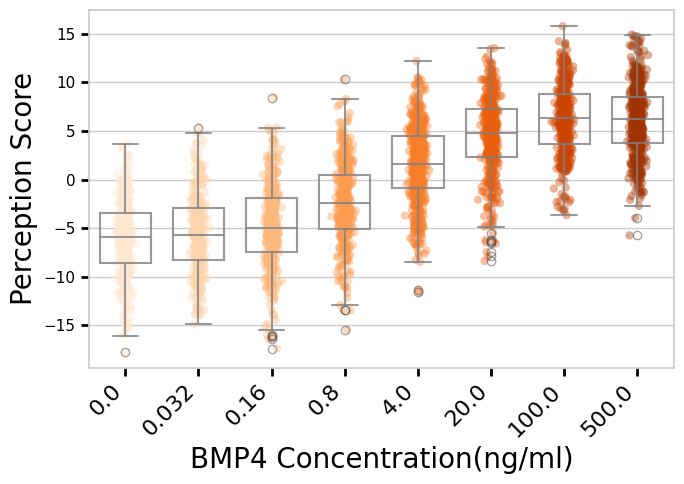

In [5]:
plot_pc1_concentration_boxplot(bmp4_model.pca_sc_fitted_df, save=True)

### Panel B: BMP4 PC1 vs H2BCITRINE

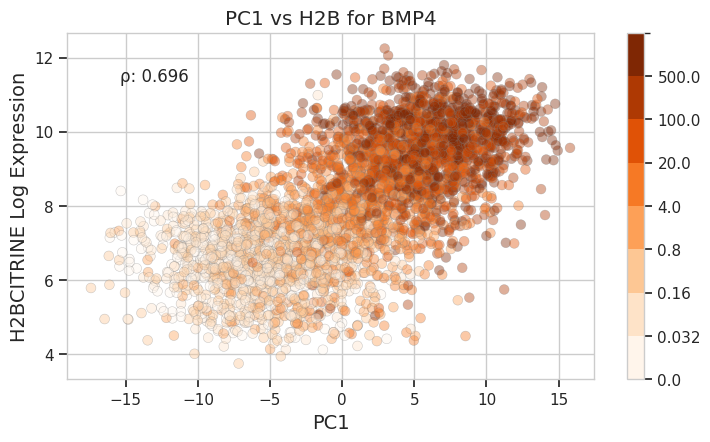

In [9]:
pca_df_bmp4 = get_pca_df_with_h2b(bmp4_model, h2b_vec)
plot_pca_vs_h2b(
    pca_df_bmp4, "BMP4", log_h2b=True, reverse=False, save=True, plot_mean=False
)

### Panel C: BMP4 Gene partial correlation with PC1 vs. KS test p-value

### Loading data generated in scripts/run_corr_ks_analysis.py

In [10]:
# #load ks test results from pickle:
with open(DATA_DIR / "ks_test_results_all_genes.pkl", "rb") as f:
    ks_results_dict_genes = pickle.load(f)
# # load global_partial_corr_genes
with open(DATA_DIR / "global_partial_corr_genes_dict.pkl", "rb") as f:
    global_partial_corr_genes_dict = pickle.load(f)

In [11]:
# BMP4
data_bmp4 = generate_ks_corr_df(
    global_partial_corr_genes_dict, ks_results_dict_genes, "BMP4"
)
data_black_bmp4, _, _, _ = mask_and_filter(data_bmp4, threshold=0.05)

#BMP6
data_bmp6 = generate_ks_corr_df(
    global_partial_corr_genes_dict, ks_results_dict_genes, "BMP6"
)
data_black_bmp6, _, _, _ = mask_and_filter(data_bmp6, threshold=0.05)

#BMP9
data_bmp9 = generate_ks_corr_df(
    global_partial_corr_genes_dict, ks_results_dict_genes, "BMP9"
)
data_black_bmp9, _, _, _ = mask_and_filter(data_bmp9, threshold=0.05)

#BMP10
data_bmp10 = generate_ks_corr_df(
    global_partial_corr_genes_dict, ks_results_dict_genes, "BMP10"
)
data_black_bmp10, _, _, _ = mask_and_filter(data_bmp10, threshold=0.05)

#TGFb1
data_tgfb = generate_ks_corr_df(
    global_partial_corr_genes_dict, ks_results_dict_genes, "TGFb1"
)
data_black_tgfb, _, _, _ = mask_and_filter(data_tgfb, threshold=0.05)

#GDF5
data_gdf5 = generate_ks_corr_df(
    global_partial_corr_genes_dict, ks_results_dict_genes, "GDF5"
)
data_black_gdf5, _, _, _ = mask_and_filter(data_gdf5, threshold=0.05)

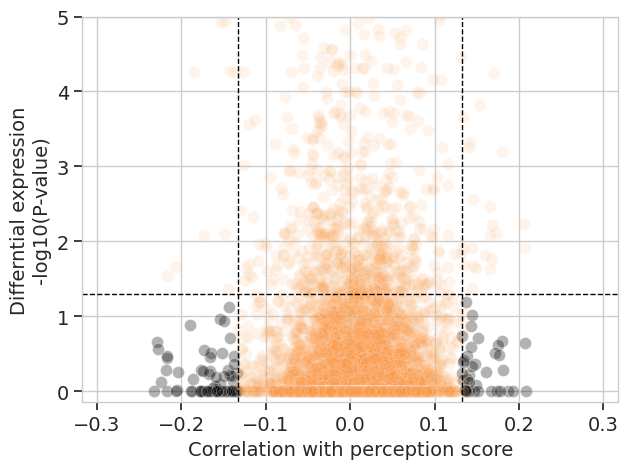

In [12]:
data_bmp4 = generate_ks_corr_df(
    global_partial_corr_genes_dict, ks_results_dict_genes, "BMP4"
)


plot_ks_corr(data_bmp4, "BMP4", gene_list=[], save=True)

### Plot (D): BMP4 Gene partial correlation with PC1 vs. KS test p-value

Similarity analysis similar to figure 3, without geting representative term and all other metrics 

#### Conducting GO analysis on the non-responsive genes of all ligands

In [12]:
gene_sets_dict = {
    "BMP4": set(data_black_bmp4.index.to_list()),
    "BMP6": set(data_black_bmp6.index.to_list()),
    "BMP9": set(data_black_bmp9.index.to_list()),
    "BMP10": set(data_black_bmp10.index.to_list()),
    "TGFB": set(data_black_tgfb.index.to_list()),
    "GDF5": set(data_black_gdf5.index.to_list()),
}

background_genes = bmp4_model.df.columns.to_list()

go_results_non_res_genes_dict = run_go_analysis(gene_sets_dict, background_genes)

Processing BMP4...
Processing BMP6...
Processing BMP9...
Processing BMP10...
Processing TGFB...
Processing GDF5...


#### Saving all GO resutls dataframes

In [13]:
save_go_results_dataframe(
    go_results_non_res_genes_dict, path=DATA_DIR / "go_analysis" / "non_res_genes_all_ligands"
)

In [10]:
go_results_non_res_genes_dict = load_go_dataframes_dict(
    path=DATA_DIR / "go_analysis" / "non_res_genes_all_ligands"
)

#### Retrieving Significant GO terms and filtering to include intersected terms from all ligands

In [11]:
sig_terms_dict, intersection_dict = extract_significant_go_terms(
    go_results_non_res_genes_dict, intersect=True
)

# Get overlapping significant terms:
non_red_dict = {term.split("(")[1].strip(")"): term.split("(")[0].strip() for term in intersection_dict['terms']}
intersection_dict_R = {
    "non_res_terms": [key for key in non_red_dict.keys()],
}

#### Saving intersected terms ID list as json file to be used in custome R script src/analysis/get_similarities.R

In [16]:
# Save json for to use in R script:
save_json_for_R(
    intersection_dict_R, DATA_DIR / "go_analysis" / "go_jsons" / "non_res_genes_all_ligs_go_terms.json"
)

#### Getting similarity scores for all non-responsive go terms 

In [17]:
env_path = "/home/labs/antebilab/guyilan/.conda/envs/paper_env"

os.environ['PATH'] = f"{env_path}/bin:" + os.environ['PATH']

# Define your custom paths here
my_input = DATA_DIR / "go_analysis" / "go_jsons" / "non_res_genes_all_ligs_go_terms.json"
my_output = DATA_DIR / "go_analysis" / "go_jsons" / "sim_results_non_res_genes_from_R.json"
r_script = BASE_DIR / "src" / "analysis" / "get_similarities.R"

# Execute R with the paths as arguments
!Rscript {r_script} {my_input} {my_output}


GOSemSim v2.36.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu. Gene Ontology Semantic Similarity Analysis Using
GOSemSim. In: Kidder B. (eds) Stem Cell Transcriptional Networks.
Methods in Molecular Biology. 2020, 2117:207-215. Humana, New York, NY.

Attaching package: ‘igraph’

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union

Loading required package: AnnotationDbi
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:igraph’:

    components, union

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:igraph’:

    normalize, path

T

#### Loading json 

In [26]:
import json

# Load sim results from R:
with open(
    DATA_DIR / "go_analysis" / "go_jsons" / "sim_results_non_res_genes_from_R.json", "r"
) as f:
    data = json.load(f)

In [27]:
go_id_name_dict, go_id_name_dict_reversed = extract_dictionaries(intersection_dict)
go_sim_mat_dict = create_go_sim_matrix(data, intersection_dict_R)

Length of non_res_terms before sim analysis: 16 and after: 13


In [28]:
simplified_go = SimplifiedGO(go_sim_mat_dict)
simplified_go.find_k_without_singletons(min_k=2).get_reordered_matrix()

Initial number of GO terms: 13, after removing singletons: 5


In [29]:
non_res_mat = update_matrix_labels(simplified_go, non_red_dict)

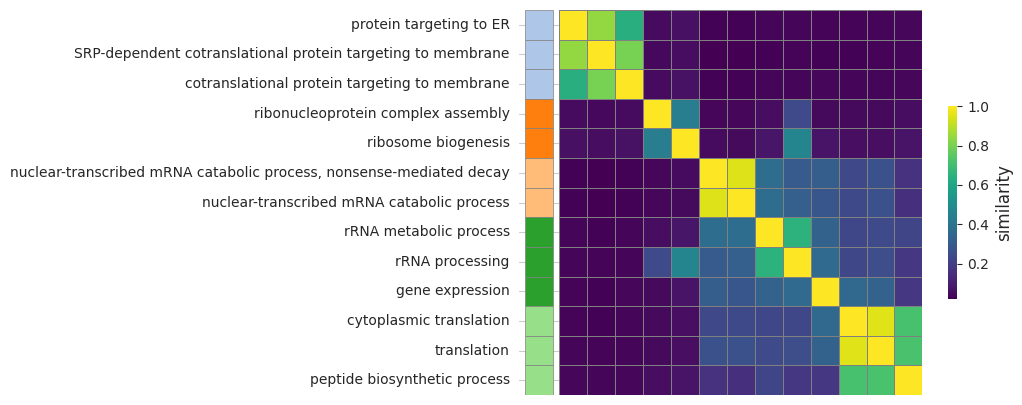

In [30]:
plot_sim_mat(non_res_mat, size=(6.5, 5), font_size=10, save=True)